# File to test functions related to vendor analysis

#### 1. Import libraries

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
from src.vendor_analysis import load_vendor_dataset
from src.vendor_analysis import prepare_vendor_data
from src.vendor_analysis import get_vendor_summary
from src.vendor_analysis import get_top_vendors_by_revenue
from src.vendor_analysis import get_bottom_vendors_by_revenue
from src.vendor_analysis import plot_vendor_revenue
from src.vendor_analysis import plot_vendor_quantity
from src.vendor_analysis import plot_vendor_revenue_and_quantity
from src.vendor_analysis import plot_vendor_revenue_and_quantity_improved
from src.vendor_analysis import plot_top_vendors_by_revenue_horizontal
from src.vendor_analysis import plot_bottom_vendors_by_revenue_horizontal
from src.vendor_analysis import plot_vendor_dashboard
from src.vendor_analysis import run_vendor_analysis


#### 2. Load data

In [3]:
df = load_vendor_dataset()
df.head()

,ID,Country,Fulfill Via,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,Côte D'Ivoire,Direct Drop,Air,2006-06-02,2006-06-02,2006-06-02,HRDT,Hiv Test,RANBAXY Fine Chemicals LTD.,...,30,19.0,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.0,780.34,NaN
1,3,Vietnam,Direct Drop,Air,2006-11-14,2006-11-14,2006-11-14,ARV,Pediatric,Aurobindo Pharma Limited,...,240,1000.0,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358.0,4521.50,NaN
2,4,Côte D'Ivoire,Direct Drop,Air,2006-08-27,2006-08-27,2006-08-27,HRDT,Hiv Test,Abbott GmbH & Co. KG,...,100,500.0,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.0,1653.78,NaN
3,15,Vietnam,Direct Drop,Air,2006-09-01,2006-09-01,2006-09-01,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,...,60,31920.0,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.0,16007.06,NaN
4,16,Vietnam,Direct Drop,Air,2006-08-11,2006-08-11,2006-08-11,ARV,Adult,Aurobindo Pharma Limited,...,60,38000.0,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.0,45450.08,NaN


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.columns

Rows: 10406
Columns: 23


Index(['ID', 'Country', 'Fulfill Via', 'Shipment Mode',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Brand', 'Dosage Form',
       'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value',
       'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

#### 3. Load vendor data

In [5]:
vendor_data = prepare_vendor_data(df)
vendor_data.head()

,ID,Vendor,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price
0,1,RANBAXY FINE CHEMICALS LTD.,30,19.0,551.0,29.00,0.97
1,3,AUROBINDO PHARMA LIMITED,240,1000.0,6200.0,6.20,0.03
2,4,ABBOTT GMBH & CO. KG,100,500.0,40000.0,80.00,0.80
3,15,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,60,31920.0,127360.8,3.99,0.07
4,16,AUROBINDO PHARMA LIMITED,60,38000.0,121600.0,3.20,0.05


In [6]:
print("Rows:", vendor_data.shape[0])
print("Columns:", vendor_data.shape[1])

vendor_data.columns

Rows: 10324
Columns: 7


Index(['ID', 'Vendor', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price'],
      dtype='object')

In [7]:
vendor_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10324 entries, 0 to 10405
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          10324 non-null  int64  
 1   Vendor                      10324 non-null  object 
 2   Unit of Measure (Per Pack)  10324 non-null  int64  
 3   Line Item Quantity          10324 non-null  int64  
 4   Line Item Value             10324 non-null  float64
 5   Pack Price                  10324 non-null  float64
 6   Unit Price                  10324 non-null  float64
dtypes: float64(3), int64(3), object(1)
memory usage: 645.2+ KB


#### 4. View Vendors information

In [8]:
vendor_summary = get_vendor_summary(vendor_data)

vendor_summary.head(10)

,Vendor,Shipment_Records,Total_Line_Item_Quantity,Total_Line_Item_Value,Average_Pack_Price,Average_Unit_Price
0,SCMS FROM RDC,5393,152519487,1.083004e+09,10.882357,0.252950
1,"ORGENICS, LTD",751,1889408,1.468514e+08,70.043968,1.014008
2,AUROBINDO PHARMA LIMITED,665,16953279,9.072049e+07,6.795865,0.142211
3,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,317,7739464,7.221367e+07,10.615804,0.283470
4,HETERO LABS LIMITED,276,26973170,4.271093e+07,5.909058,0.152826
5,CIPLA LIMITED,174,6237700,3.957769e+07,7.478793,0.143563
6,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),346,873999,2.944506e+07,39.292543,44.270780
7,STRIDES ARCOLAB LIMITED,93,7985106,2.248547e+07,3.754301,0.070645
8,"TRINITY BIOTECH, PLC",356,636696,2.051219e+07,39.713511,1.738567
9,S. BUYS WHOLESALER,711,8080077,9.844021e+06,19.134121,29.339283


#### 5. Top and Botton vendor by revenue

In [9]:
top_5_vendors = get_top_vendors_by_revenue(vendor_data, top_n=5)
top_5_vendors

,Vendor,Shipment_Records,Total_Line_Item_Quantity,Total_Line_Item_Value,Average_Pack_Price,Average_Unit_Price
0,SCMS FROM RDC,5393,152519487,1.083004e+09,10.882357,0.252950
1,"ORGENICS, LTD",751,1889408,1.468514e+08,70.043968,1.014008
2,AUROBINDO PHARMA LIMITED,665,16953279,9.072049e+07,6.795865,0.142211
3,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,317,7739464,7.221367e+07,10.615804,0.283470
4,HETERO LABS LIMITED,276,26973170,4.271093e+07,5.909058,0.152826


In [10]:
bottom_5_vendors = get_bottom_vendors_by_revenue(vendor_data, bottom_n=5)
bottom_5_vendors

,Vendor,Shipment_Records,Total_Line_Item_Quantity,Total_Line_Item_Value,Average_Pack_Price,Average_Unit_Price
0,"RAININ INSTRUMENT, LLC.",1,2,46.90,23.45,0.08
1,INVERNESS MEDICAL INNOVATIONS SOUTH AFRICA (PT...,2,10,715.00,72.50,1.85
2,BIO-RAD LABORATORIES PTY LTD. (SOUTH AFRICA),1,1,750.29,750.29,41.68
3,RANBAXY FINE CHEMICALS LTD.,2,38,1102.00,29.00,0.97
4,OMEGA DIAGNOSTICS LTD,1,44,1375.00,31.25,1.25


#### 6. Visualizations

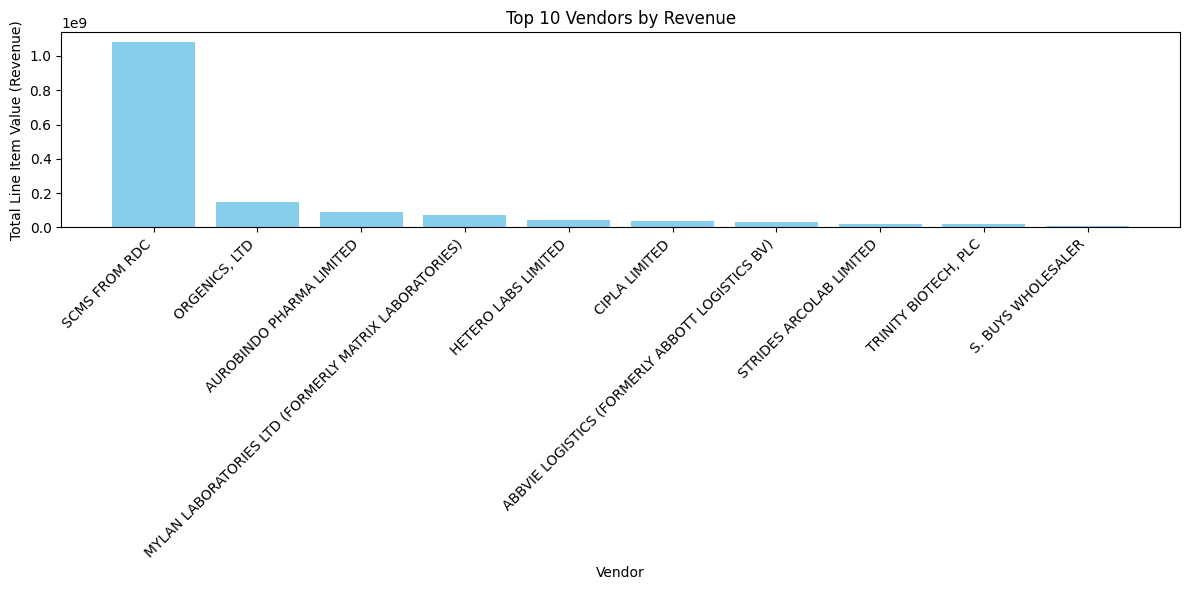

In [11]:
# vendor orders by revenue
plot_vendor_revenue(vendor_data, top_n=10)

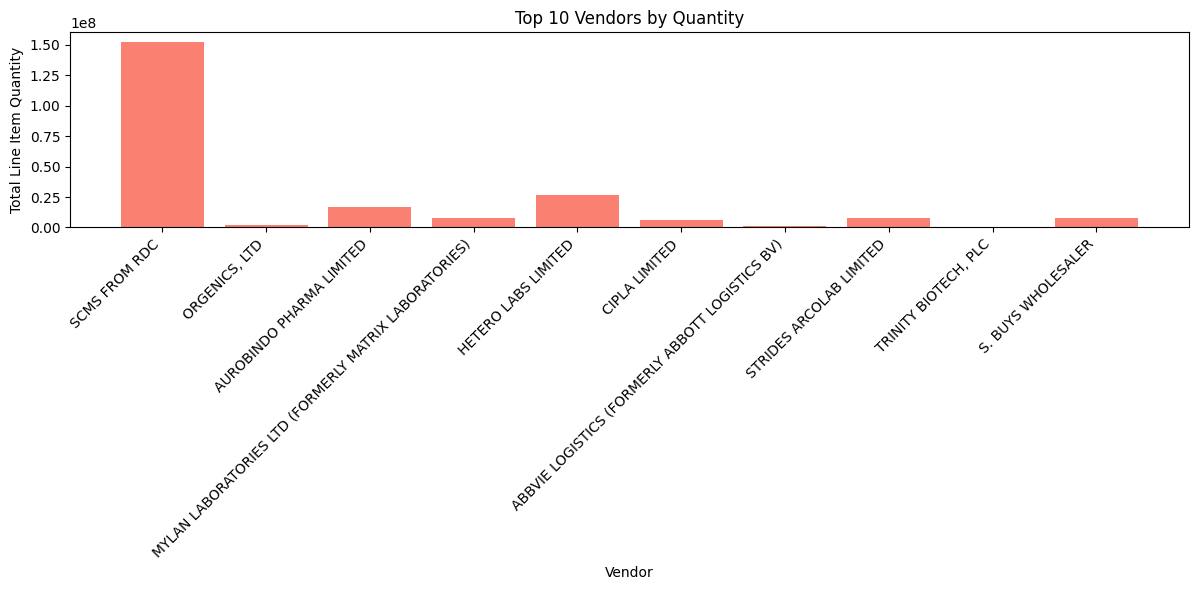

In [12]:
# vendor orders by quantity
plot_vendor_quantity(vendor_data, top_n=10)

E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:243: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors["Vendor"], rotation=45, ha="right")


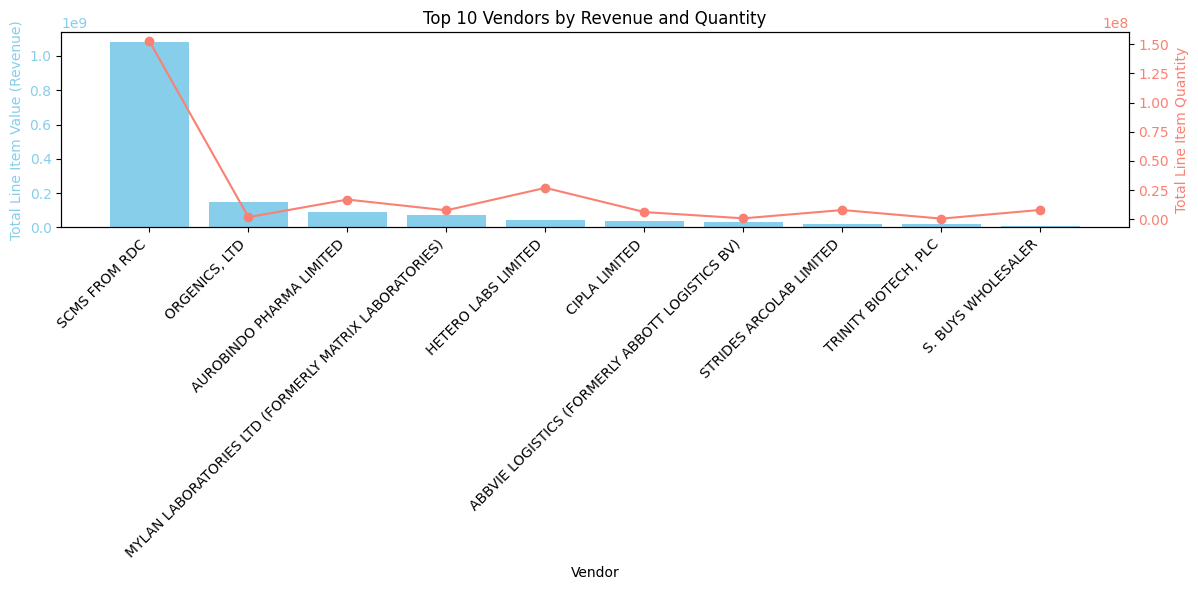

In [13]:
# vendor orders by revenue and quantity
plot_vendor_revenue_and_quantity(vendor_data, top_n=10)

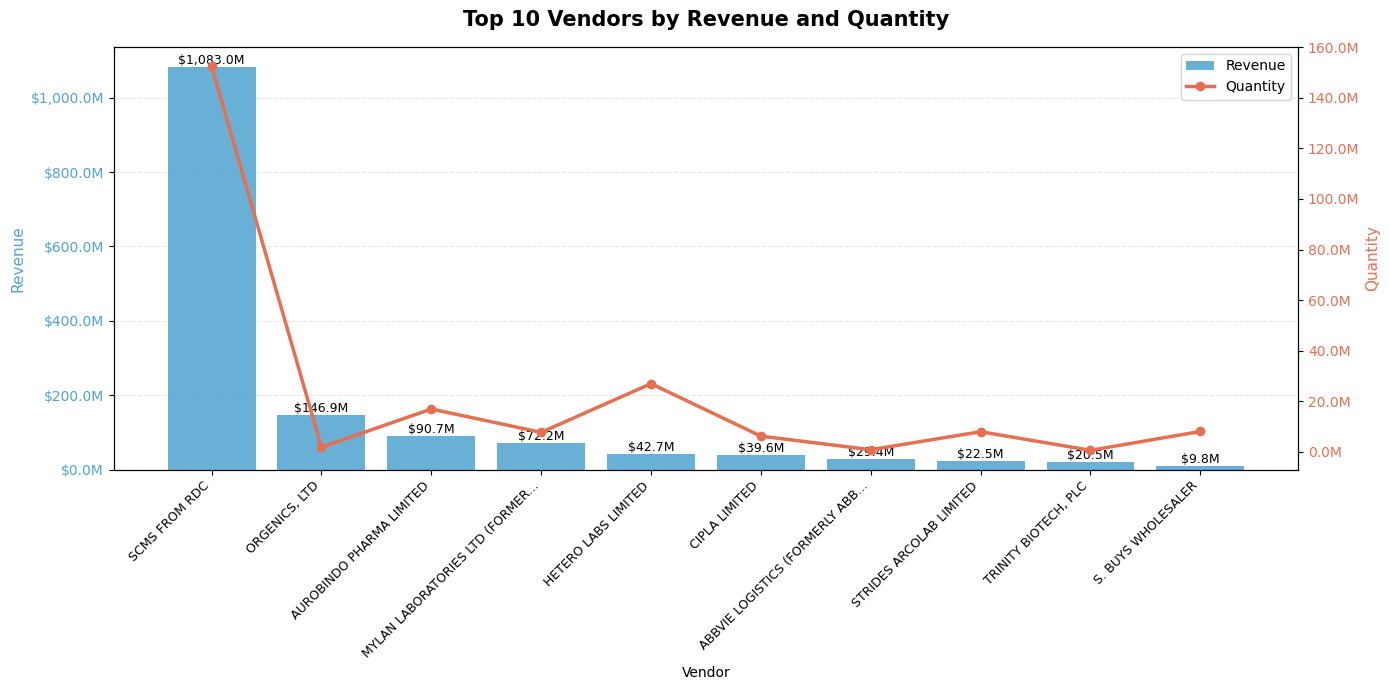

In [14]:
# vendor orders by revenue and quantity with improved formatting
plot_vendor_revenue_and_quantity_improved(vendor_data, top_n=10)

E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


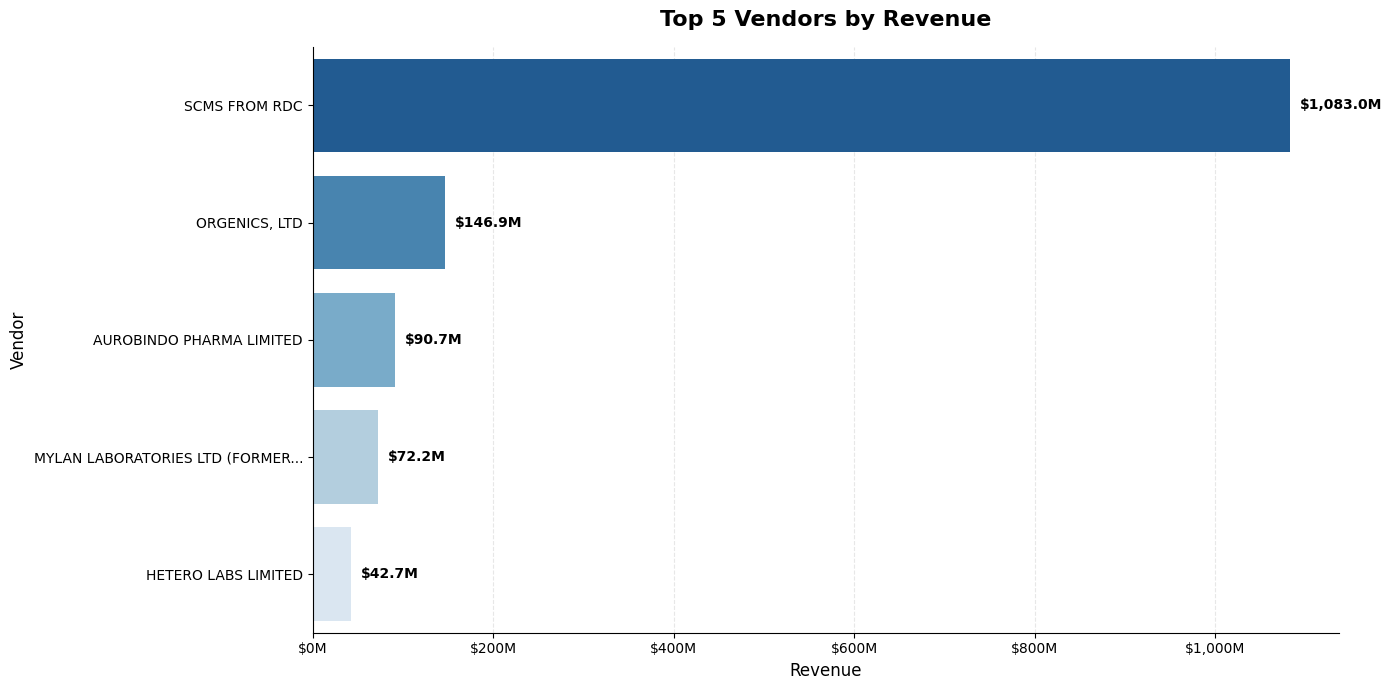

In [15]:
# top vendors by revenue with horizontal bars
plot_top_vendors_by_revenue_horizontal(vendor_data, top_n=5)

E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:489: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


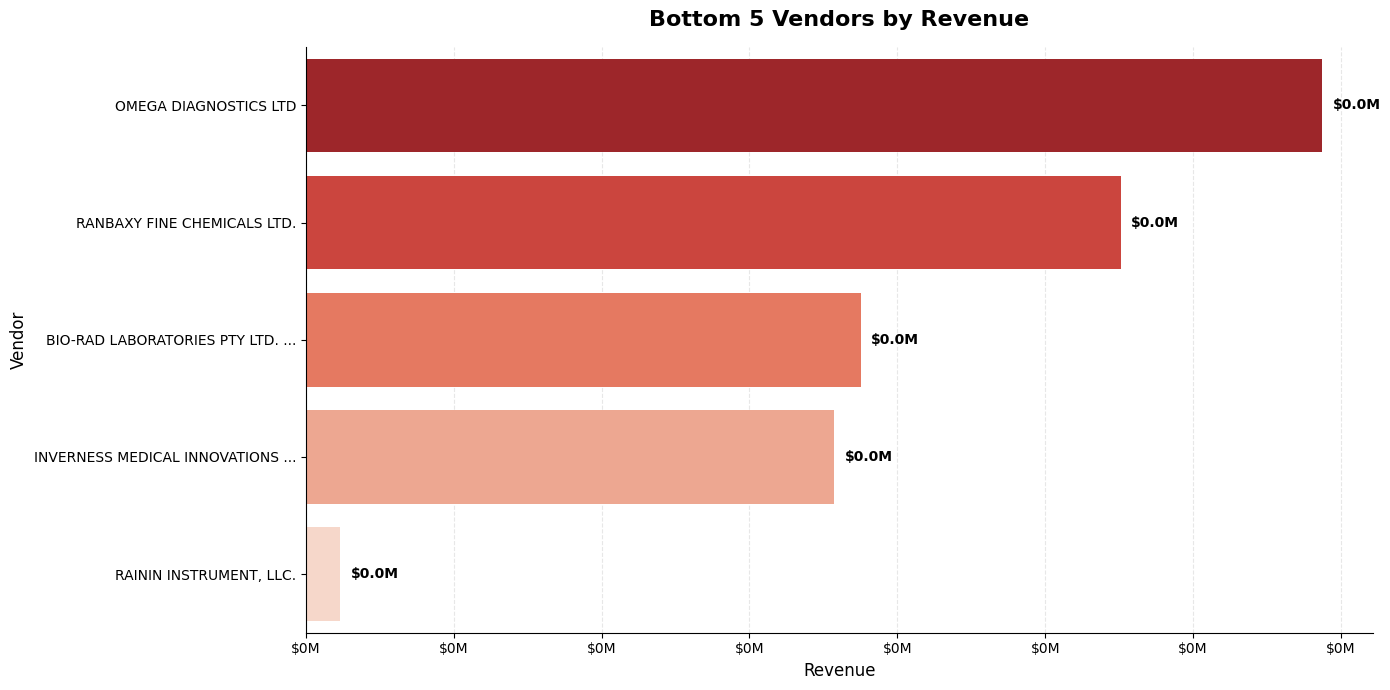

In [16]:
# bottom vendors by revenue with horizontal bars
plot_bottom_vendors_by_revenue_horizontal(vendor_data, bottom_n=5)

#### 7. Create a Dashboard

E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:489: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


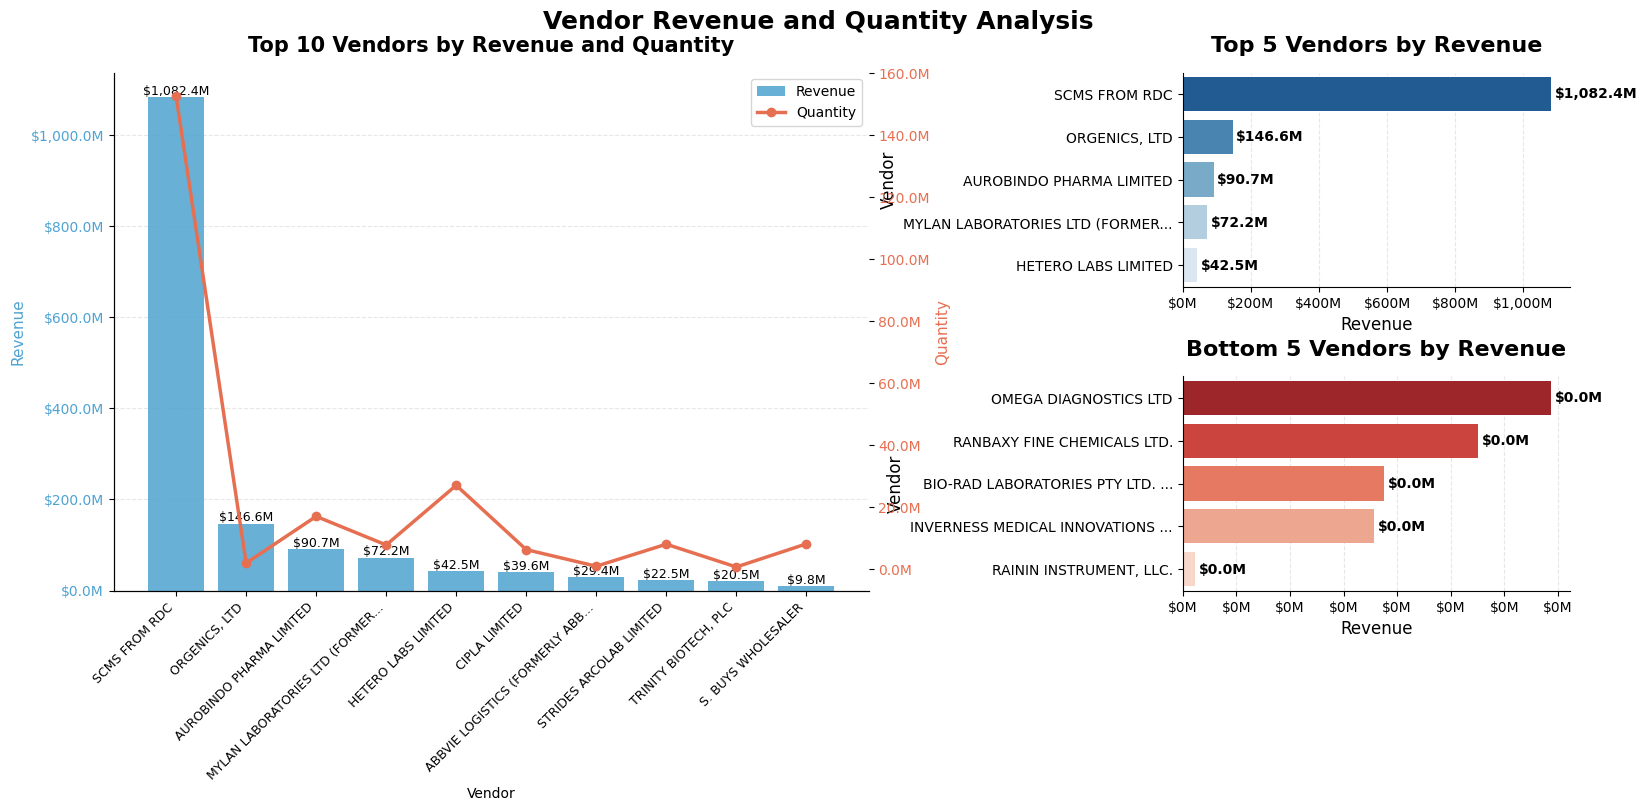

In [6]:
# plot vendor dashboard
plot_vendor_dashboard(vendor_data, top_n=10, top_revenue_n=5, bottom_revenue_n=5)

#### 8. Complete and finished workflow


Vendor Summary:
                                              Vendor  Shipment_Records  \
0                                      SCMS FROM RDC              5393   
1                                      ORGENICS, LTD               751   
2                           AUROBINDO PHARMA LIMITED               665   
3  MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...               317   
4                                HETERO LABS LIMITED               276   
5                                      CIPLA LIMITED               174   
6    ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)               346   
7                            STRIDES ARCOLAB LIMITED                93   
8                               TRINITY BIOTECH, PLC               356   
9                                 S. BUYS WHOLESALER               711   

   Total_Line_Item_Quantity  Total_Line_Item_Value  Average_Pack_Price  \
0               152519487.0           1.082446e+09           10.876164   
1                 18

E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
E:\jcuenca\OneDrive - GUSCanada\4toTerm\01_AgileSoftware\02_Assignment2\supply\Supply-Chain-Shipment-Summary-Tool\src\vendor_analysis.py:489: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


{'vendor_data':           ID                                             Vendor  \
 0          1                        RANBAXY FINE CHEMICALS LTD.   
 1          3                           AUROBINDO PHARMA LIMITED   
 2          4                               ABBOTT GMBH & CO. KG   
 3         15  SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...   
 4         16                           AUROBINDO PHARMA LIMITED   
 ...      ...                                                ...   
 10401  86818                                      SCMS FROM RDC   
 10402  86819                                      SCMS FROM RDC   
 10403  86821                                      SCMS FROM RDC   
 10404  86822                                      SCMS FROM RDC   
 10405  86823                                      SCMS FROM RDC   
 
        Unit of Measure (Per Pack)  Line Item Quantity  Line Item Value  \
 0                              30                19.0           551.00   
 1               

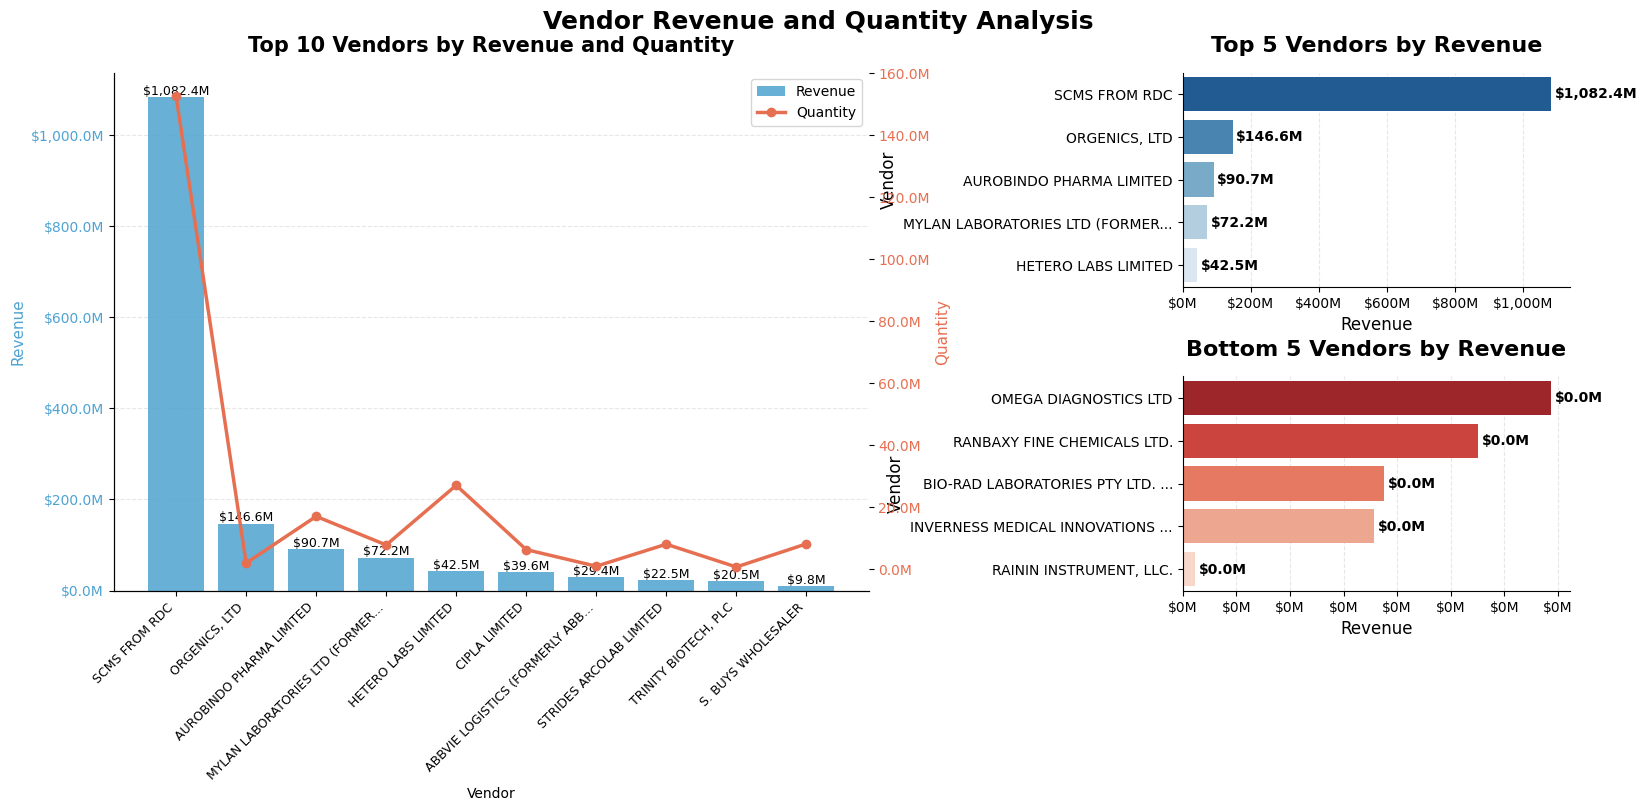

In [7]:
# run the vendor analysis workflow
run_vendor_analysis()